Data Wrangling
Grouping and aggregating data
Missing data-types, dealing with them
data inputation
outliers-detecting and handling


In [94]:
#Data Wrangling- subsetting and filtering
import pandas as pd
data_load=r'C:\Users\MURERWA DANIEL\Documents\GitHub\DataScience\Data_Dataset\tested.csv'
df=pd.read_csv(data_load)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [95]:
df.shape
#df.info
df.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                                Kelly, Mr. James    male  34.5      0      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                       Myles, Mr. Thomas Francis    male  62.0      0      0   
3                                Wirz, Mr. Albert    male  27.0      0      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
..                     

In [96]:
male_df=df['Sex']=='male'
print(male_df)
df[male_df]['Age'].mean().round()

0       True
1      False
2       True
3       True
4      False
       ...  
413     True
414    False
415     True
416     True
417     True
Name: Sex, Length: 418, dtype: bool


np.float64(30.0)

In [97]:
female_df=df['Sex']=='female'
print(female_df)
df[female_df]['Age'].mean().round()

0      False
1       True
2      False
3      False
4       True
       ...  
413    False
414     True
415    False
416    False
417    False
Name: Sex, Length: 418, dtype: bool


np.float64(30.0)

In [98]:
male_df2=(df['Sex']=='male')&(df['Pclass']==1)
df[male_df2]['Survived'].value_counts()



Survived
0    57
Name: count, dtype: int64

In [99]:
df[df['Sex']=='female']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
410,1302,1,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S


In [100]:
female_df2=(df['Sex']=='female')&(df['Pclass']==1)
df[female_df2].Survived.value_counts(0)



Survived
1    50
Name: count, dtype: int64

In [101]:
#grouping and aggregating data

df.groupby('Sex')
df.groupby('Pclass')['Fare'].mean().round()

Pclass
1    94.0
2    22.0
3    12.0
Name: Fare, dtype: float64

In [102]:
df.groupby(['Pclass','Sex'])['Fare'].mean().round()

Pclass  Sex   
1       female    116.0
        male       76.0
2       female     26.0
        male       20.0
3       female     14.0
        male       12.0
Name: Fare, dtype: float64

In [103]:
df.Sex.value_counts()

Sex
male      266
female    152
Name: count, dtype: int64

In [104]:
df.groupby(['Pclass','Sex']).count()

PassengerId  Survived  Name  Age  SibSp  Parch  Ticket  Fare  \
Pclass Sex                                                                    
1      female           50        50    50   48     50     50      50    50   
       male             57        57    57   50     57     57      57    57   
2      female           30        30    30   29     30     30      30    30   
       male             63        63    63   59     63     63      63    63   
3      female           72        72    72   50     72     72      72    72   
       male            146       146   146   96    146    146     146   145   

               Cabin  Embarked  
Pclass Sex                      
1      female     40        50  
       male       40        57  
2      female      3        30  
       male        4        63  
3      female      1        72  
       male        3       146

In [105]:
df.groupby('Pclass')['Sex'].value_counts()

Pclass  Sex   
1       male       57
        female     50
2       male       63
        female     30
3       male      146
        female     72
Name: count, dtype: int64

In [106]:
#Missing Data
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [107]:
df.dropna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
14,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.1750,E31,S
24,916,1,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C
26,918,1,1,"Ostby, Miss. Helene Ragnhild",female,22.0,0,1,113509,61.9792,B36,C
28,920,0,1,"Brady, Mr. John Bertram",male,41.0,0,0,113054,30.5000,A21,S
...,...,...,...,...,...,...,...,...,...,...,...,...
404,1296,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,17765,27.7208,D40,C
405,1297,0,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q


In [108]:
df.drop(columns='Cabin')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S


In [109]:
#for numeric missing data
#replacing with mean mode and median
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [110]:
df.Age.fillna(df.median(), inplace=True)

TypeError: Cannot convert [['Kelly, Mr. James' 'Wilkes, Mrs. James (Ellen Needs)'
  'Myles, Mr. Thomas Francis' ... 'Saether, Mr. Simon Sivertsen'
  'Ware, Mr. Frederick' 'Peter, Master. Michael J']
 ['male' 'female' 'male' ... 'male' 'male' 'male']
 ['330911' '363272' '240276' ... 'SOTON/O.Q. 3101262' '359309' '2668']
 [nan nan nan ... nan nan nan]
 ['Q' 'S' 'Q' ... 'S' 'S' 'C']] to numeric

In [ ]:
df.Embarked.mode()
type(df.Embarked.mode())

pandas.core.series.Series

In [ ]:
df.Embarked.fillna('S', inplace=True)

C:\Users\MURERWA DANIEL\AppData\Local\Temp\ipykernel_13628\4256457318.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Embarked.fillna('S', inplace=True)


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
import numpy as np
import pandas as pd
sales={ 'sales': [10, np.nan, np.nan, 100]}
df1=pd.DataFrame(sales)
df


,sales
0,10.0
1,NaN
2,NaN
3,100.0


In [ ]:
df1['sales'].interpolate()

0     10.0
1     40.0
2     70.0
3    100.0
Name: sales, dtype: float64

<Axes: ylabel='Frequency'>

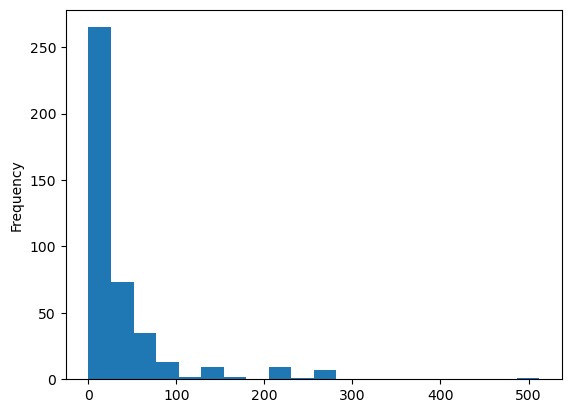

In [118]:
#outliers -detecting and handling
df.Fare.plot(kind='hist', bins=20)


<Axes: >

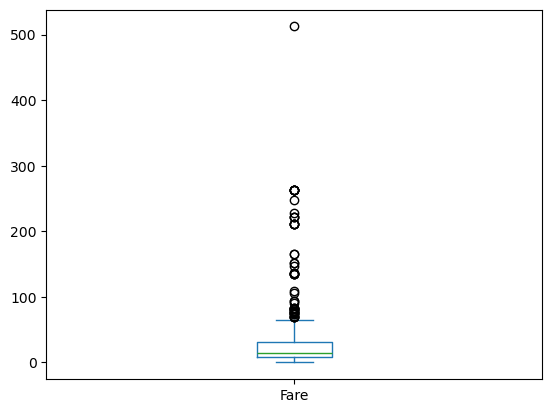

In [123]:
#outliers -detecting and handling
df.Fare.plot(kind='box')


<Axes: ylabel='Frequency'>

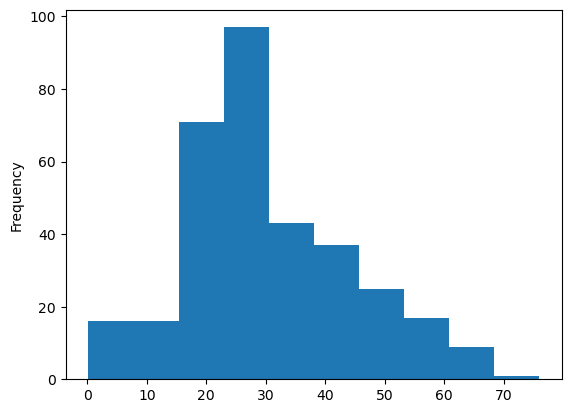

In [120]:
df.Age.plot(kind='hist')

In [119]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


<Axes: >

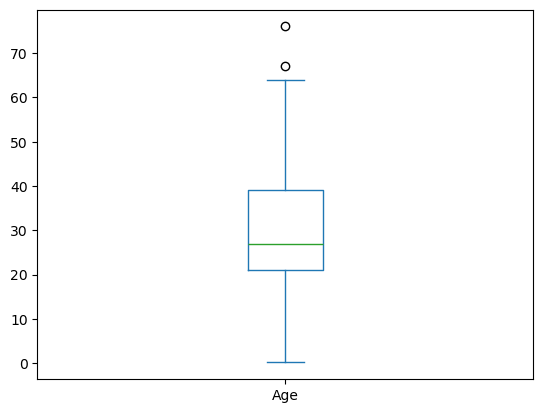

In [121]:
df.Age.plot(kind='box')

In [126]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)

In [128]:
IQR=Q3-Q1
IQR

np.float64(18.0)

In [135]:
#Outliers
outliers=df[(df['Age']<Q1-1.2*IQR)|(df['Age']>Q3+1.2*IQR)]
outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
13,905,0,2,"Howard, Mr. Benjamin",male,63.0,1,0,24065,26.0000,NaN,S
81,973,0,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S
114,1006,1,1,"Straus, Mrs. Isidor (Rosalie Ida Blun)",female,63.0,1,0,PC 17483,221.7792,C55 C57,S
142,1034,0,1,"Ryerson, Mr. Arthur Larned",male,61.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C
179,1071,1,1,"Compton, Mrs. Alexander Taylor (Mary Eliza Ing...",female,64.0,0,2,PC 17756,83.1583,E45,C
193,1085,0,2,"Lingane, Mr. John",male,61.0,0,0,235509,12.3500,NaN,Q
236,1128,0,1,"Warren, Mr. Frank Manley",male,64.0,1,0,110813,75.2500,D37,C
305,1197,1,1,"Crosby, Mrs. Edward Gifford (Catherine Elizabe...",female,64.0,1,1,112901,26.5500,B26,S


In [ ]:
#chicago Crime Dataset